### Importando banco de dados

In [344]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sharmajicoder/e-commerce-sales-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\lucas\.cache\kagglehub\datasets\sharmajicoder\e-commerce-sales-dataset\versions\1


In [345]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [346]:
# Listar arquivos disponíveis
files = os.listdir(path)
print("Arquivos disponíveis:", files)

# Carregar o primeiro arquivo CSV encontrado
csv_file = [f for f in files if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Fazendo cópia do DataFrame para manipulação
df1 = df.copy().reset_index(drop=True)
df1.shape
df1.head()

Arquivos disponíveis: ['amazon_sales_dataset.csv']


,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,without,Home,Furniture,Doyle-Jordan,3,42467.79,0.26,60.85,94339.34,Card
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,school,Home,Furniture,Davis LLC,2,36138.76,0.24,112.96,55043.88,COD
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.43,UPI
3,A10003,2026-01-18,2026-01-15,2026-01-20,Delivered,C4012,Angela Collins,India,Kentucky,South Margaretshire,...,step,Electronics,Laptop,"Sandoval, Buckley and Solis",1,18487.99,0.06,114.15,17492.86,Card
4,A10004,2026-01-27,2026-01-04,2026-01-23,Delivered,C1328,David Davidson DDS,India,North Dakota,Velasquezview,...,bit,Home,Kitchen,"Key, Bautista and Bowen",1,1742.25,0.10,40.47,1608.49,UPI


### Estudando o banco de dados

In [347]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        10000 non-null  object 
 1   order_date      10000 non-null  object 
 2   ship_date       10000 non-null  object 
 3   delivery_date   10000 non-null  object 
 4   order_status    10000 non-null  object 
 5   customer_id     10000 non-null  object 
 6   customer_name   10000 non-null  object 
 7   country         10000 non-null  object 
 8   state           10000 non-null  object 
 9   city            10000 non-null  object 
 10  product_id      10000 non-null  object 
 11  product_name    10000 non-null  object 
 12  category        10000 non-null  object 
 13  sub_category    10000 non-null  object 
 14  brand           10000 non-null  object 
 15  quantity        10000 non-null  int64  
 16  unit_price      10000 non-null  float64
 17  discount        10000 non-null  

In [348]:
# Convertendo colunas de data para o formato datetime
df1['order_date'] = pd.to_datetime(df1['order_date'])
df1['ship_date'] = pd.to_datetime(df1['ship_date'])
df1['delivery_date'] = pd.to_datetime(df1['delivery_date'])
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        10000 non-null  object        
 1   order_date      10000 non-null  datetime64[ns]
 2   ship_date       10000 non-null  datetime64[ns]
 3   delivery_date   10000 non-null  datetime64[ns]
 4   order_status    10000 non-null  object        
 5   customer_id     10000 non-null  object        
 6   customer_name   10000 non-null  object        
 7   country         10000 non-null  object        
 8   state           10000 non-null  object        
 9   city            10000 non-null  object        
 10  product_id      10000 non-null  object        
 11  product_name    10000 non-null  object        
 12  category        10000 non-null  object        
 13  sub_category    10000 non-null  object        
 14  brand           10000 non-null  object        
 15  qua

In [349]:
df1['payment_method'].unique()

array(['Card', 'COD', 'UPI', 'NetBanking'], dtype=object)

In [350]:
print(df1['delivery_date'].max())
print(df1['order_date'].min())

2026-02-10 00:00:00
2026-01-01 00:00:00


In [351]:
df1['category'].unique()

array(['Home', 'Electronics', 'Fashion'], dtype=object)

In [352]:
df1['discount'].unique()

array([0.26, 0.24, 0.14, 0.06, 0.1 , 0.22, 0.19, 0.03, 0.12, 0.27, 0.3 ,
       0.02, 0.13, 0.25, 0.28, 0.21, 0.09, 0.2 , 0.16, 0.29, 0.04, 0.  ,
       0.07, 0.08, 0.17, 0.15, 0.11, 0.18, 0.05, 0.01, 0.23])

In [353]:
df1['faturamento_bruto'] = df1['quantity'] * df1['unit_price']
df1['diferenca_absoluta'] = df1['faturamento_bruto'] - df1['total_sales']
df1['percentual_perda'] = (df1['diferenca_absoluta'] / df1['faturamento_bruto']) * 100

In [354]:
df1.head(3)

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method,faturamento_bruto,diferenca_absoluta,percentual_perda
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,Doyle-Jordan,3,42467.79,0.26,60.85,94339.34,Card,127403.37,33064.03,25.95
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,Davis LLC,2,36138.76,0.24,112.96,55043.88,COD,72277.52,17233.64,23.84
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,Watson and Sons,4,47148.93,0.14,64.11,162256.43,UPI,188595.72,26339.29,13.97


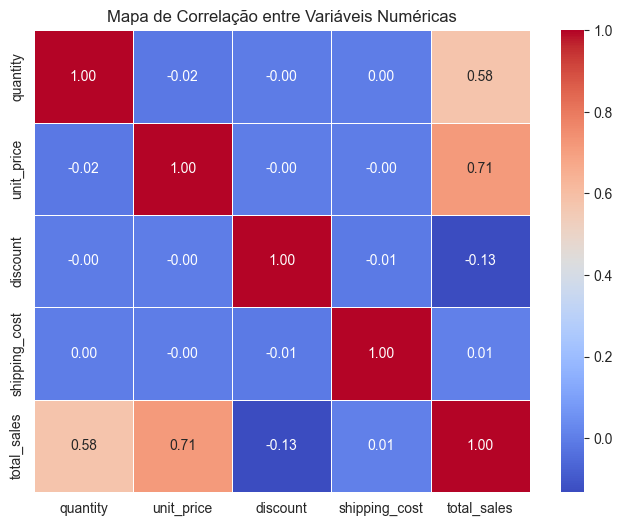

In [355]:
# Selecionando apenas colunas numéricas
numeric_cols = ['quantity', 'unit_price', 'discount', 'shipping_cost', 'total_sales']

# Criar matriz de correlação
corr_matrix = df[numeric_cols].corr()

# Plotar mapa de calor
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Mapa de Correlação entre Variáveis Numéricas")
plt.show()


### 1. Health Check de Vendas: Concentração geográfica, métodos de pagamento e impacto dos descontos no faturamento.

1.1 Quais são as regiões que possuem a maior concentração dos clientes?

In [356]:
# Criando a tabela de concentração geográfica a partir do df1
concentracao_geo = df1.groupby(['state', 'city']).agg({
    'order_id': 'count',              # Quantidade de pedidos na região
    'total_sales': 'sum'               # Faturamento total na região
}).reset_index()

# Ordenando pelos estados com maior faturamento para facilitar a leitura
concentracao_geo = concentracao_geo.sort_values(by='total_sales', ascending=False)

# Renomeando as colunas para o relatório
concentracao_geo.columns = ['Estado', 'Cidade', 'Qtd_Pedidos', 'Faturamento_Total']

concentracao_geo.head(10)

,Estado,Cidade,Qtd_Pedidos,Faturamento_Total
8979,Virginia,Lake Michael,3,295696.42
9389,West Virginia,Lake Megan,2,272944.30
33,Alabama,East Jennifer,2,272254.09
7493,Pennsylvania,New Jennifer,2,267542.01
7145,Oklahoma,South Christopherview,2,265509.65
9225,Washington,North David,2,265272.41
8282,Tennessee,Port Christian,2,265267.51
5246,Nebraska,Flynnborough,1,249155.53
7623,Rhode Island,East Michellemouth,1,248605.11
4129,Massachusetts,North William,2,246062.72


1.1.2 Quais são os 10 estados com maior receita líquida?

C:\Users\lucas\AppData\Local\Temp\ipykernel_37868\1041619123.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lucratividade_regional.head(10),


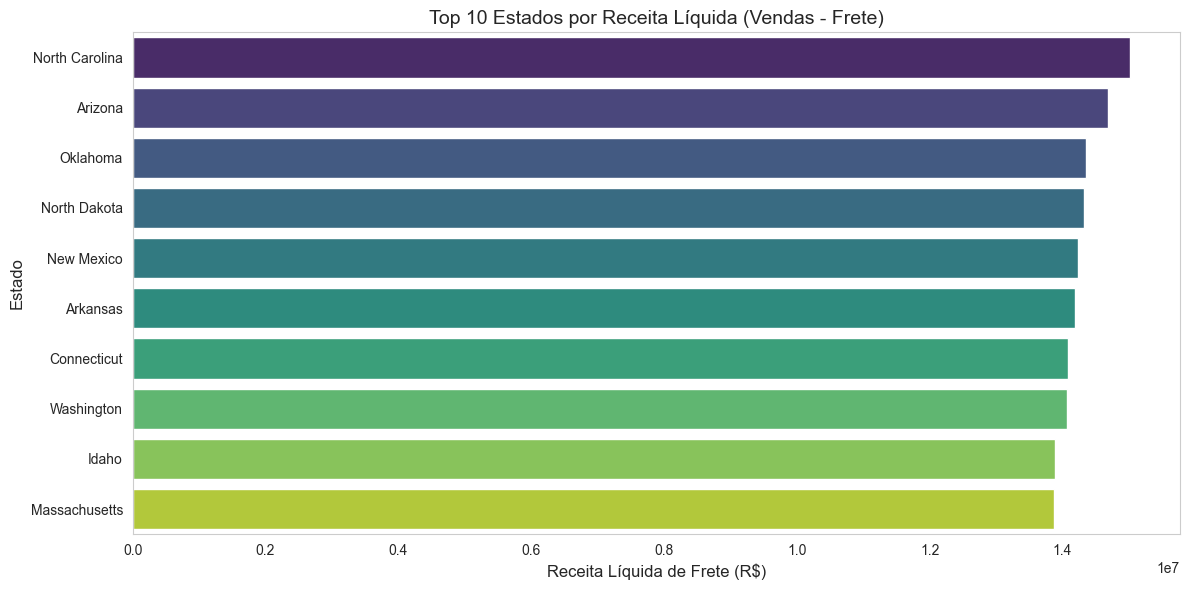

            state  receita_liquida_frete  total_sales  shipping_cost
0  North Carolina            15018160.32  15037672.64       19512.32
1         Arizona            14689703.64  14709889.31       20185.67
2        Oklahoma            14359245.06  14377373.99       18128.93
3    North Dakota            14330347.85  14347950.79       17602.94
4      New Mexico            14237556.57  14255195.93       17639.36
5        Arkansas            14188998.57  14207028.54       18029.97
6     Connecticut            14087580.21  14106742.70       19162.49
7      Washington            14062623.27  14080910.74       18287.47
8           Idaho            13887037.69  13904589.39       17551.70
9   Massachusetts            13871559.60  13887312.12       15752.52


In [357]:
# 1. Calcular a Receita Líquida de Frete no df1
df1['receita_liquida_frete'] = df1['total_sales'] - df1['shipping_cost']

# 2. Agrupar por estado
lucratividade_regional = df1.groupby('state').agg({
    'receita_liquida_frete': 'sum',
    'total_sales': 'sum',
    'shipping_cost': 'sum'
}).sort_values(by='receita_liquida_frete', ascending=False).reset_index()

# 3. Visualização em Gráfico de Barras
plt.figure(figsize=(12, 6))
sns.barplot(data=lucratividade_regional.head(10), 
            x='receita_liquida_frete', 
            y='state', 
            palette='viridis')

plt.title('Top 10 Estados por Receita Líquida (Vendas - Frete)', fontsize=14)
plt.xlabel('Receita Líquida de Frete (R$)', fontsize=12)
plt.ylabel('Estado', fontsize=12)

plt.tight_layout()
plt.show()

# Exibir a tabela para precisão numérica
print(lucratividade_regional.head(10))


1.2 Comparativo do volume de vendas entre as categorias

C:\Users\lucas\AppData\Local\Temp\ipykernel_37868\1899180009.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='quantity', data=sales_by_category, palette='viridis')


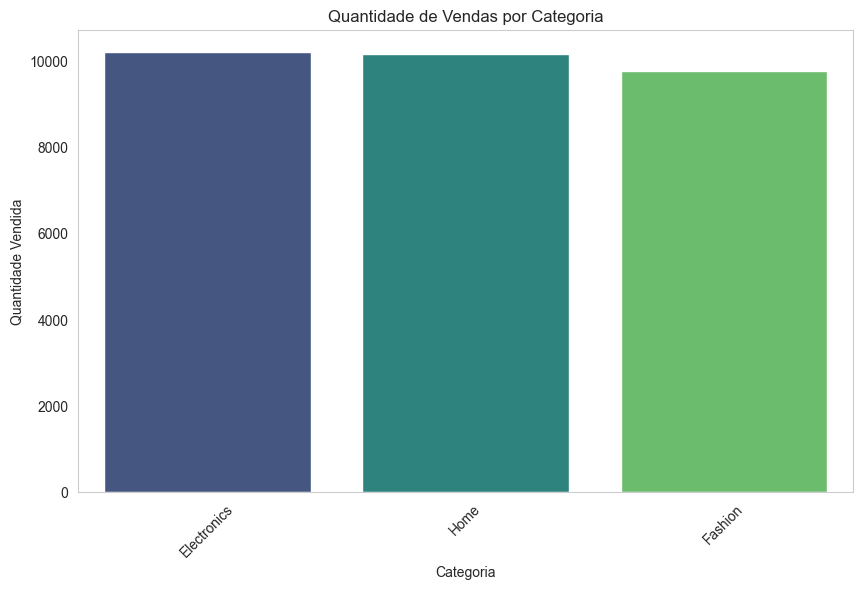

In [358]:
# Agrupar vendas por categoria
sales_by_category = df.groupby('category')['quantity'].sum().reset_index()

# Ordenar para facilitar a leitura
sales_by_category = sales_by_category.sort_values(by='quantity', ascending=False)

# Plotar gráfico de barras verticais
plt.figure(figsize=(10,6))
sns.barplot(x='category', y='quantity', data=sales_by_category, palette='viridis')

plt.title("Quantidade de Vendas por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Quantidade Vendida")
plt.xticks(rotation=45)
plt.show()


1.3 Quais categorias/subcategorias que mais sofrem desconto?

In [359]:
# Agrupando por Categoria e Subcategoria para analisar os descontos
analise_desconto = df1.groupby(['category', 'sub_category']).agg({
    'discount': ['mean', 'sum'],       # Média e Total de desconto
    'quantity': 'sum',                 # Volume de vendas
    'total_sales': 'sum'               # Faturamento líquido
}).reset_index()

# Ajustando o nome das colunas para facilitar a leitura
analise_desconto.columns = [
    'Categoria', 'Subcategoria', 'Media_Desconto', 
    'Total_Desconto_Valor', 'Qtd_Vendida', 'Faturamento_Liquido'
]

# Ordenando pelas subcategorias que tiveram maior valor total de desconto
analise_desconto = analise_desconto.sort_values(by='Total_Desconto_Valor', ascending=False)

# Define o formato de exibição para duas casas decimais
pd.options.display.float_format = '{:.2f}'.format

print("--- Análise de Descontos por Categoria e Subcategoria ---")
analise_desconto

--- Análise de Descontos por Categoria e Subcategoria ---


,Categoria,Subcategoria,Media_Desconto,Total_Desconto_Valor,Qtd_Vendida,Faturamento_Liquido
5,Home,Furniture,0.15,261.56,5247,111843677.98
4,Fashion,Footwear,0.15,254.40,4962,104005232.00
6,Home,Kitchen,0.15,243.90,4914,102920088.08
3,Fashion,Clothing,0.15,233.32,4806,104003832.75
2,Electronics,Mobile,0.15,174.56,3508,74281306.95
1,Electronics,Laptop,0.15,166.49,3439,74661262.80
0,Electronics,Accessories,0.15,165.45,3268,70413704.99


1.4 Qual é o impacto que os descontos estão fazendo no volume de vendas? Será que realmente os descontos realmente estão convertendo vendas?

C:\Users\lucas\AppData\Local\Temp\ipykernel_37868\4248244138.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vendas_por_desconto, x='tem_desconto', y='quantity', palette='coolwarm')


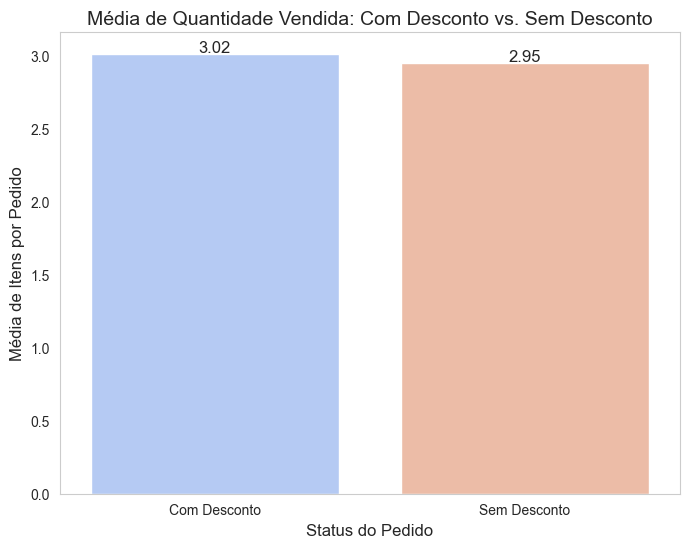

In [360]:
# Criando uma coluna temporária para identificar se houve desconto
df1['tem_desconto'] = df1['discount'].apply(lambda x: 'Com Desconto' if x > 0 else 'Sem Desconto')

# Agrupando para ver a média de quantidade
vendas_por_desconto = df1.groupby('tem_desconto')['quantity'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=vendas_por_desconto, x='tem_desconto', y='quantity', palette='coolwarm')

plt.title('Média de Quantidade Vendida: Com Desconto vs. Sem Desconto', fontsize=14)
plt.xlabel('Status do Pedido', fontsize=12)
plt.ylabel('Média de Itens por Pedido', fontsize=12)

# Adicionando os valores nas barras para facilitar a leitura
for i, valor in enumerate(vendas_por_desconto['quantity']):
    plt.text(i, valor + 0.01, f'{valor:.2f}', ha='center', fontsize=12)

plt.show()

1.5 Quais são os métodos de pagamentos mais utilizados pelos clientes?

C:\Users\lucas\AppData\Local\Temp\ipykernel_37868\3080608300.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pagamentos, x='Metodo', y='Qtd_Pedidos', palette='viridis')


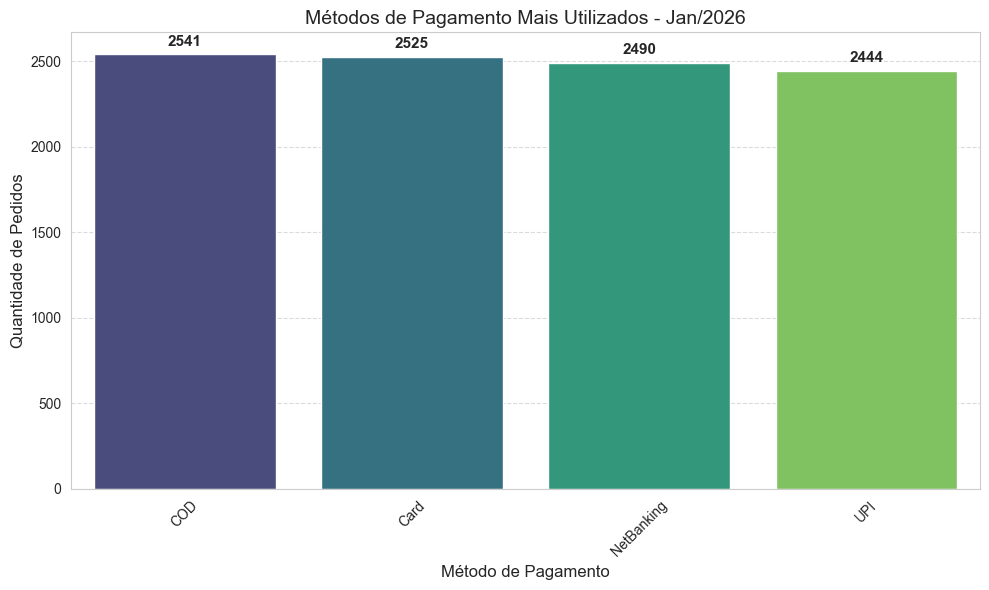

In [361]:
# Agrupando a contagem de pedidos por método de pagamento
pagamentos = df1['payment_method'].value_counts().reset_index()
pagamentos.columns = ['Metodo', 'Qtd_Pedidos']

plt.figure(figsize=(10, 6))

# Criando o gráfico de barras verticais
sns.barplot(data=pagamentos, x='Metodo', y='Qtd_Pedidos', palette='viridis')

# Adicionando rótulos de dados nas barras para precisão
for i, valor in enumerate(pagamentos['Qtd_Pedidos']):
    plt.text(i, valor + 50, f'{valor}', ha='center', fontsize=11, fontweight='bold')

plt.title('Métodos de Pagamento Mais Utilizados - Jan/2026', fontsize=14)
plt.xlabel('Método de Pagamento', fontsize=12)
plt.ylabel('Quantidade de Pedidos', fontsize=12)
plt.xticks(rotation=45) # Inclina os nomes para não sobrepor
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

1.6 Há relação entre o método de pagamento e o tipo de produto que os clientes compram?

--- Frequência: Categoria vs. Método de Pagamento ---
payment_method  COD  Card  NetBanking  UPI
category                                  
Electronics     849   871         831  801
Fashion         821   854         811  783
Home            871   800         848  860


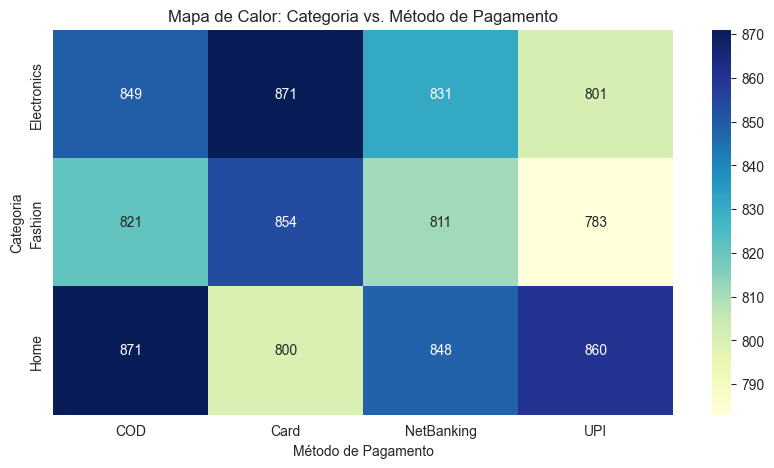

In [362]:
# Criando a tabela cruzada (Crosstab)
tabela_cruzada = pd.crosstab(df1['category'], df1['payment_method'])

# Exibindo a tabela formatada
print("--- Frequência: Categoria vs. Método de Pagamento ---")
print(tabela_cruzada)

# Visualizando como um Heatmap para facilitar o diagnóstico (Opcional, mas recomendado)
plt.figure(figsize=(10, 5))
sns.heatmap(tabela_cruzada, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Mapa de Calor: Categoria vs. Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Categoria')
plt.show()

1.7 Em quais dias da semana há maior volume de vendas?

1.7.1 Volume de Vendas por Dia da Semana

C:\Users\lucas\AppData\Local\Temp\ipykernel_37868\806840298.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vendas_dia_semana, x='Dia_da_Semana', y='Qtd_Pedidos', palette='Blues_d')


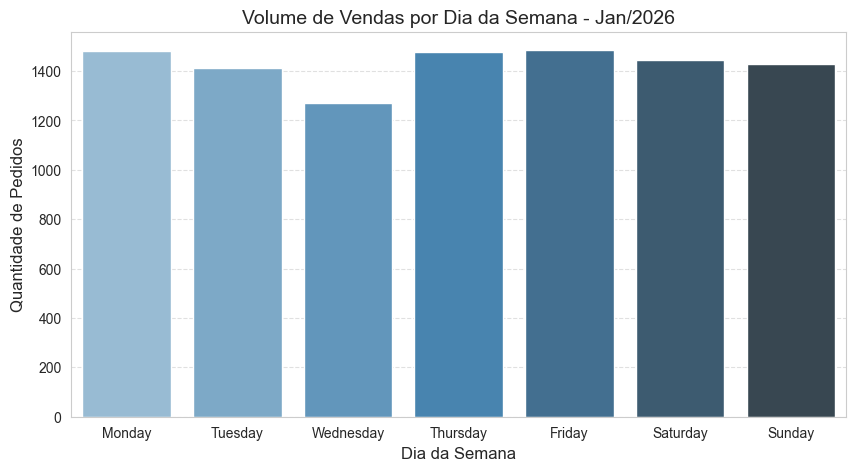

In [363]:
# Garantir que a coluna de data está no formato correto e extrair o dia da semana
df1['day_of_week'] = df1['order_date'].dt.day_name()

# Ordenar os dias para o gráfico não ficar bagunçado
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Agrupando os dados
vendas_dia_semana = df1['day_of_week'].value_counts().reindex(dias_ordenados).reset_index()
vendas_dia_semana.columns = ['Dia_da_Semana', 'Qtd_Pedidos']

plt.figure(figsize=(10, 5))
sns.barplot(data=vendas_dia_semana, x='Dia_da_Semana', y='Qtd_Pedidos', palette='Blues_d')

plt.title('Volume de Vendas por Dia da Semana - Jan/2026', fontsize=14)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Quantidade de Pedidos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

1.7.2 Comparativo: 1ª Quinzena vs. 2ª Quinzena

C:\Users\lucas\AppData\Local\Temp\ipykernel_37868\759706259.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=faturamento_quinzena, x='quinzena', y='total_sales', palette='Set2')


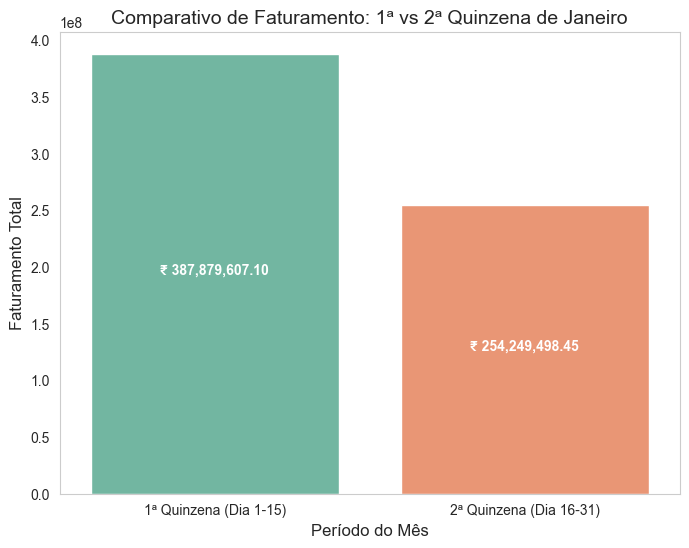

In [364]:
# Criando a regra para as quinzenas
df1['quinzena'] = df1['order_date'].dt.day.apply(lambda x: '1ª Quinzena (Dia 1-15)' if x <= 15 else '2ª Quinzena (Dia 16-31)')

# Agrupando por faturamento
faturamento_quinzena = df1.groupby('quinzena')['total_sales'].sum().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=faturamento_quinzena, x='quinzena', y='total_sales', palette='Set2')

# Formatação de valores para o storytelling
for i, valor in enumerate(faturamento_quinzena['total_sales']):
    plt.text(i, valor/2, f'₹ {valor:,.2f}', ha='center', color='white', fontweight='bold')

plt.title('Comparativo de Faturamento: 1ª vs 2ª Quinzena de Janeiro', fontsize=14)
plt.xlabel('Período do Mês', fontsize=12)
plt.ylabel('Faturamento Total', fontsize=12)

plt.show()

 - Quantos clientes compraram mais de uma vez? Dentre esses clientes, qual é a média de frequência?

- Métricas de Retenção e Frequência

In [365]:
# 1. Agrupando por cliente para ver o comportamento individual
comportamento_cliente = df1.groupby('customer_id').agg({
    'order_id': 'count',
    'total_sales': 'sum'
}).reset_index()

# 2. Identificando recorrentes (pedidos > 1)
clientes_recorrentes = comportamento_cliente[comportamento_cliente['order_id'] > 1]

# 3. Criando a tabela de resumo
resumo_fidelidade = pd.DataFrame({
    'Métrica': [
        'Total de Clientes Únicos', 
        'Clientes que compraram + de uma vez', 
        'Percentual de Retenção (%)',
        'Média de Frequência (Recorrentes)',
        'Ticket Médio por Cliente (Geral)'
    ],
    'Valor': [
        comportamento_cliente['customer_id'].nunique(),
        len(clientes_recorrentes),
        (len(clientes_recorrentes) / comportamento_cliente['customer_id'].nunique()) * 100,
        clientes_recorrentes['order_id'].mean(),
        comportamento_cliente['total_sales'].mean()
    ]
})

pd.options.display.float_format = '{:.2f}'.format
print("--- Tabela de Retenção e Valor do Cliente ---")
resumo_fidelidade

--- Tabela de Retenção e Valor do Cliente ---


,Métrica,Valor
0,Total de Clientes Únicos,6016.00
1,Clientes que compraram + de uma vez,2780.00
2,Percentual de Retenção (%),46.21
3,Média de Frequência (Recorrentes),2.43
4,Ticket Médio por Cliente (Geral),106736.89


### 2. Eficiência Logística : Onde a entrega é mais rápida? Onde o frete é abusivo?

In [366]:
# Criando o DataFrame focado em Logística
df_logistic = df1[[
    'order_id', 'order_date', 'ship_date', 'delivery_date',
    'state', 'city', 'product_name', 'category', 'sub_category',
    'brand', 'shipping_cost', 'total_sales'
]].copy()

# Calcular tempos sem sobrescrever datas
df_logistic['dispatch_time'] = (df_logistic['ship_date'] - df_logistic['order_date']).dt.days
df_logistic['delivery_time'] = (df_logistic['delivery_date'] - df_logistic['order_date']).dt.days

# Filtrar apenas registros válidos (sem tempos negativos)
df_logistic = df_logistic[
    (df_logistic['dispatch_time'] >= 0) &
    (df_logistic['delivery_time'] >= 0)
]

# Métrica de impacto de custo (Frete sobre Venda)
df_logistic['shipping_impact_%'] = (df_logistic['shipping_cost'] / df_logistic['total_sales']) * 100

# Conferir primeiras linhas
df_logistic.head(10)


,order_id,order_date,ship_date,delivery_date,state,city,product_name,category,sub_category,brand,shipping_cost,total_sales,dispatch_time,delivery_time,shipping_impact_%
1,A10001,2026-01-20,2026-02-03,2026-02-03,Tennessee,Madisonmouth,school,Home,Furniture,Davis LLC,112.96,55043.88,14,14,0.21
5,A10005,2026-01-05,2026-01-12,2026-01-11,South Carolina,Ryanburgh,through,Home,Furniture,Lee Inc,105.47,29633.81,7,6,0.36
6,A10006,2026-01-04,2026-01-10,2026-01-21,Colorado,Turnerville,page,Electronics,Mobile,Wade-Jackson,29.90,156361.68,6,17,0.02
9,A10009,2026-01-24,2026-01-26,2026-02-10,South Carolina,Kendraton,example,Fashion,Clothing,"Carroll, Barnes and Harris",144.57,74836.31,2,17,0.19
11,A10011,2026-01-17,2026-01-17,2026-02-06,Georgia,Lawrenceland,experience,Home,Furniture,Johns and Sons,57.50,15576.08,0,20,0.37
12,A10012,2026-01-15,2026-01-24,2026-01-20,Texas,North Jordan,firm,Home,Kitchen,Leblanc LLC,60.57,48757.78,9,5,0.12
13,A10013,2026-01-02,2026-01-06,2026-01-10,California,South Heather,series,Electronics,Accessories,Monroe PLC,120.87,3950.30,4,8,3.06
17,A10017,2026-01-01,2026-02-08,2026-01-20,Oklahoma,Mariafort,themselves,Home,Kitchen,Steele-Butler,27.80,23670.32,38,19,0.12
28,A10028,2026-01-05,2026-01-21,2026-01-24,Pennsylvania,Dwaynehaven,set,Electronics,Laptop,Valdez Ltd,45.35,28490.53,16,19,0.16
30,A10030,2026-01-16,2026-01-21,2026-02-10,Pennsylvania,North Sara,recognize,Electronics,Accessories,Shaw Group,125.58,176016.99,5,25,0.07


In [367]:
df_logistic['shipping_impact_%'].mean()

np.float64(0.49174613664923555)

In [368]:
# Verificando se há valores negativos ou inconsistentes nos tempos de despacho e entrega
df_logistic['dispatch_time'].unique()

array([14,  7,  6,  2,  0,  9,  4, 38, 16,  5, 11, 21, 28,  1, 18, 24, 40,
        8, 15, 10, 35, 33, 12, 36, 30, 22, 25, 20,  3, 23, 19, 27, 34, 39,
       17, 32, 26, 29, 37, 31, 13])

In [369]:
df_logistic['delivery_time'].unique()

array([14,  6, 17, 20,  5,  8, 19, 25, 29,  3, 34,  2, 21, 10, 11, 30, 16,
       12, 24,  7, 39,  9, 33, 37, 27,  4, 26, 28, 15,  0, 32,  1, 18, 31,
       23, 35, 36, 13, 22, 40, 38])

----

2.1 Análise de Custo

- Quais produtos que possuem o maior custo de envio?

In [370]:
# 1. Agrupando por produto para calcular o custo médio de envio
# Usamos a média (mean) para entender o custo padrão de enviar cada unidade desse produto
top_frete_produtos = df_logistic.groupby('product_name')['shipping_cost'].mean().sort_values(ascending=False).head(10).reset_index()

# Exibindo a tabela para conferência
top_frete_produtos

,product_name,shipping_cost
0,however,149.81
1,get,147.43
2,year,147.34
3,quickly,144.90
4,say,144.39
5,woman,144.26
6,plant,143.79
7,research,142.75
8,north,142.70
9,certainly,141.74


- Quais fornecedores possuem maior custo de envio?

In [371]:
# Agrupando por marca para calcular o custo médio de envio
top_frete_marcas = (
    df_logistic.groupby('brand')['shipping_cost']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Renomeando colunas para clareza
top_frete_marcas.columns = ['Marca', 'Custo_Médio_Envio']

print("--- Top 10 Marcas por Custo Médio de Envio ---")
top_frete_marcas


--- Top 10 Marcas por Custo Médio de Envio ---


,Marca,Custo_Médio_Envio
0,"Adams, Barr and Sullivan",149.95
1,Schultz-Smith,149.91
2,"Herrera, Mcgee and Gaines",149.90
3,Garcia-Garcia,149.86
4,Hunter-Shepherd,149.82
5,"Chavez, Martin and Solomon",149.81
6,Miles Ltd,149.68
7,Morgan PLC,149.65
8,Roy-Lynn,149.53
9,Strong-Moyer,149.51


- Calcular o impacto do valor do frete sobre o faturamento total. Quais regiões (States/Cities) têm o frete mais caro proporcionalmente?

- Calcular o impacto do valor do frete sobre o faturamento total
Por que? No e-commerce, se o frete custa mais que 15-20% do produto, a operação pode estar perdendo dinheiro. Quais regiões (States/Cities) têm o frete mais caro proporcionalmente? Isso é um insight de logística puro.

In [372]:
# 1. Agrupando por Estado e Cidade para ver o impacto médio
frete_proporcional = df_logistic.groupby(['state', 'city']).agg({
    'shipping_impact_%': 'mean',
    'total_sales': 'sum',
    'shipping_cost': 'sum',
}).reset_index()

# 2. Filtrando apenas regiões com impacto crítico (acima de 20%)

# Ordenamos pelo impacto para ver onde a situação é mais grave
regioes_criticas = frete_proporcional[frete_proporcional['shipping_impact_%'] > 20].sort_values(by='shipping_impact_%', ascending=False)

# Formatando a exibição para o seu relatório
pd.options.display.float_format = '{:.2f}'.format
print("--- Regiões com Frete Crítico (> 20% do valor da venda) ---")
regioes_criticas.head(15).reset_index(drop=True)

--- Regiões com Frete Crítico (> 20% do valor da venda) ---


,state,city,shipping_impact_%,total_sales,shipping_cost
0,Oregon,Port Nancy,35.24,357.79,126.07
1,Idaho,Freemanton,25.38,411.51,104.44
2,Nevada,Jeffreyview,22.85,555.71,126.99
3,New Mexico,Kellyville,22.76,388.38,88.39
4,Tennessee,South Aaron,21.47,585.79,125.76
5,North Carolina,Cherylborough,20.78,701.04,145.65


----

2.2 Análise de Lead Time

- Qual é o tempo médio geral para o envio dos produtos? 

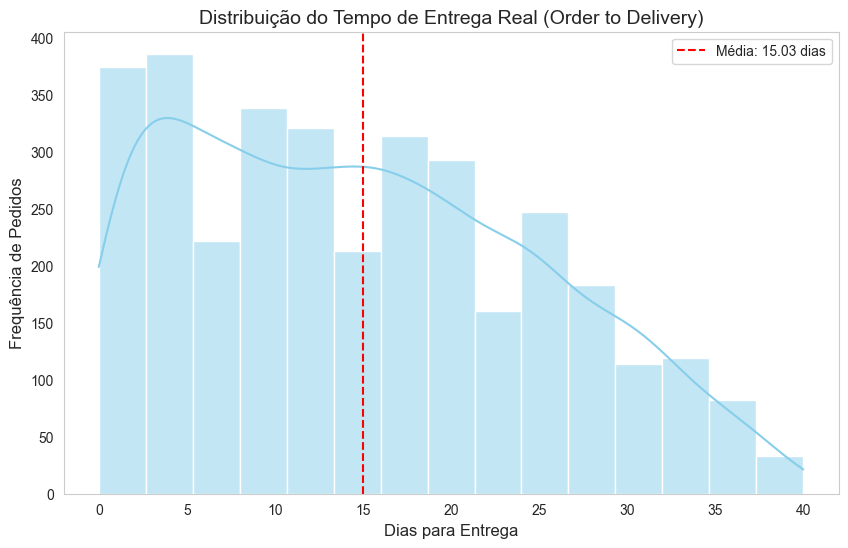

O tempo médio geral de entrega em Janeiro/2026 foi de 15.03 dias.


In [373]:
plt.figure(figsize=(10, 6))

# Gerando o histograma do tempo de entrega real
sns.histplot(df_logistic['delivery_time'], bins=15, kde=True, color='skyblue')

# Adicionando linha de média geral
media_geral = df_logistic['delivery_time'].mean()
plt.axvline(media_geral, color='red', linestyle='--', label=f'Média: {media_geral:.2f} dias')

plt.title('Distribuição do Tempo de Entrega Real (Order to Delivery)', fontsize=14)
plt.xlabel('Dias para Entrega', fontsize=12)
plt.ylabel('Frequência de Pedidos', fontsize=12)
plt.legend()

plt.show()

print(f"O tempo médio geral de entrega em Janeiro/2026 foi de {media_geral:.2f} dias.")

- Qual é o tempo médio geral para o envio por categoria e subcategoria?

In [374]:
# Agrupando por Categoria e Subcategoria para visão macro
lead_time_macro = (
    df_logistic
    .groupby(['category', 'sub_category'])
    .agg(
        Tempo_Médio_Total=('delivery_time', 'mean'),
        Média_Despacho=('dispatch_time', 'mean'),
        Qtd_Pedidos=('order_id', 'count')
    )
    .reset_index()
)

# Calcular tempo de transporte
lead_time_macro['Tempo_Médio_Transporte'] = (
    lead_time_macro['Tempo_Médio_Total'] - lead_time_macro['Média_Despacho']
)

# Reordenar colunas
lead_time_macro = lead_time_macro[
    ['category', 'sub_category', 'Média_Despacho', 'Tempo_Médio_Transporte','Tempo_Médio_Total', 'Qtd_Pedidos']
]
# Ordenar pela média de entrega (descendente)
lead_time_macro = lead_time_macro.sort_values(by='Tempo_Médio_Total', ascending=False).reset_index(drop=True)

print("--- Lead Time por Categoria e Subcategoria ---")
lead_time_macro


--- Lead Time por Categoria e Subcategoria ---


,category,sub_category,Média_Despacho,Tempo_Médio_Transporte,Tempo_Médio_Total,Qtd_Pedidos
0,Electronics,Laptop,13.55,2.14,15.69,382
1,Fashion,Footwear,14.97,0.45,15.41,560
2,Electronics,Mobile,15.81,-0.59,15.22,437
3,Electronics,Accessories,15.54,-0.41,15.13,370
4,Home,Kitchen,14.36,0.75,15.10,529
5,Fashion,Clothing,15.36,-0.87,14.48,532
6,Home,Furniture,15.07,-0.63,14.44,589


In [375]:
# Criar coluna de tempos médios diretamente
df1['Tempo_Total'] = (df1['delivery_date'] - df1['order_date']).dt.days
df1['Tempo_Despacho'] = (df1['ship_date'] - df1['order_date']).dt.days

# Agrupando por marca
lead_time_brand = (
    df1.groupby('brand')
    .agg(
        Tempo_Médio_Total=('Tempo_Total', 'mean'),
        Média_Despacho=('Tempo_Despacho', 'mean'),
        Qtd_Pedidos=('order_id', 'count')
    )
    .reset_index()
)

# Calcular tempo médio de transporte
lead_time_brand['Tempo_Médio_Transporte'] = (
    lead_time_brand['Tempo_Médio_Total'] - lead_time_brand['Média_Despacho']
)

# Reordenar colunas
lead_time_brand = lead_time_brand[
    ['brand', 'Média_Despacho', 'Tempo_Médio_Transporte', 'Tempo_Médio_Total', 'Qtd_Pedidos']
]

# Ordenar pela média de entrega (descendente)
lead_time_brand = lead_time_brand.sort_values(by='Tempo_Médio_Total', ascending=False).reset_index(drop=True)

print("--- Lead Time por Marca ---")
lead_time_brand.head(10)  # Mostra as 10 piores marcas


--- Lead Time por Marca ---


,brand,Média_Despacho,Tempo_Médio_Transporte,Tempo_Médio_Total,Qtd_Pedidos
0,Elliott-Norris,5.00,35.00,40.00,1
1,"Walsh, Pierce and Haynes",14.00,26.00,40.00,1
2,Holland Inc,17.00,23.00,40.00,1
3,Sanders-Thomas,9.00,31.00,40.00,1
4,Turner and Sons,5.00,35.00,40.00,1
5,"Young, Cook and Alvarez",12.00,27.00,39.00,1
6,Rose-English,13.00,26.00,39.00,1
7,"Jones, Miller and Thompson",4.00,35.00,39.00,1
8,"Johnson, Ryan and Jones",35.00,4.00,39.00,1
9,Jordan and Sons,18.00,21.00,39.00,1


In [376]:
df_logistic[df_logistic['delivery_time'] == 40]

,order_id,order_date,ship_date,delivery_date,state,city,product_name,category,sub_category,brand,shipping_cost,total_sales,dispatch_time,delivery_time,shipping_impact_%
843,A10843,2026-01-01,2026-01-10,2026-02-10,Alaska,Moniquestad,state,Fashion,Footwear,Sanders-Thomas,31.50,28288.12,9,40,0.11
5370,A15370,2026-01-01,2026-01-18,2026-02-10,Michigan,Jennifermouth,two,Electronics,Mobile,Holland Inc,136.46,159695.05,17,40,0.09
8231,A18231,2026-01-01,2026-01-06,2026-02-10,Texas,Dennisberg,one,Fashion,Footwear,Turner and Sons,35.26,36721.81,5,40,0.10
9039,A19039,2026-01-01,2026-01-06,2026-02-10,Arkansas,East Lori,country,Electronics,Mobile,Elliott-Norris,96.05,17964.61,5,40,0.53
9456,A19456,2026-01-01,2026-01-15,2026-02-10,Alabama,New Garyberg,model,Home,Kitchen,"Walsh, Pierce and Haynes",37.34,37114.41,14,40,0.10


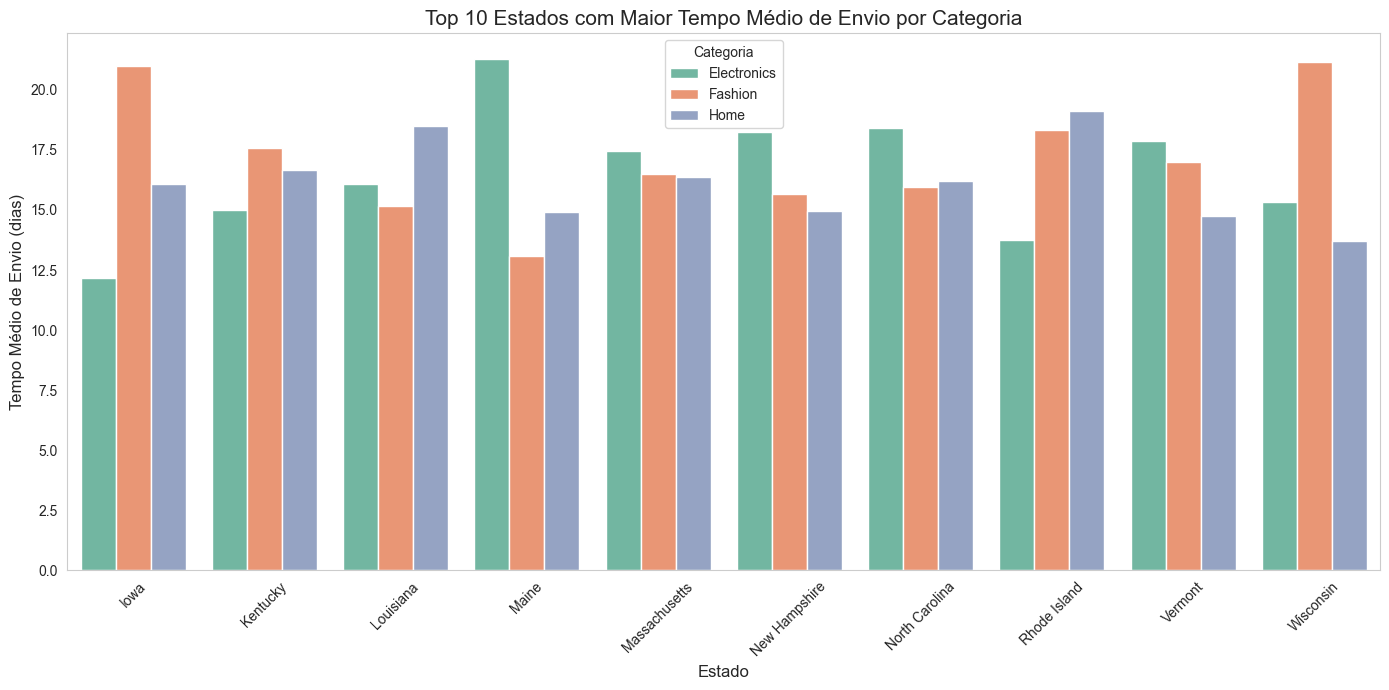

In [377]:
# Agrupando por estado e categoria, calculando tempo médio de envio
tempo_envio_regiao_categoria = (
    df_logistic.groupby(['state', 'category'])['dispatch_time']
    .mean()
    .reset_index()
)

# Selecionar apenas os Top 10 estados com maior tempo médio de envio
top_10_estados = (
    tempo_envio_regiao_categoria.groupby('state')['dispatch_time']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Filtrar os dados originais para manter apenas os estados do Top 10
dados_top_10 = tempo_envio_regiao_categoria[
    tempo_envio_regiao_categoria['state'].isin(top_10_estados['state'])
]

# Criando o gráfico
plt.figure(figsize=(14, 7))
sns.barplot(
    data=dados_top_10,
    x='state',
    y='dispatch_time',
    hue='category',
    palette='Set2'
)

# Customização
plt.title('Top 10 Estados com Maior Tempo Médio de Envio por Categoria', fontsize=15)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Tempo Médio de Envio (dias)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Categoria')

plt.tight_layout()
plt.show()



- Quais subcategorias são mais afetadas pelo preço do frete?

In [378]:
df_logistic.groupby(['category', 'sub_category'])['shipping_impact_%'].mean().reset_index().sort_values(by='shipping_impact_%', ascending=False)

,category,sub_category,shipping_impact_%
0,Electronics,Accessories,0.61
4,Fashion,Footwear,0.55
1,Electronics,Laptop,0.54
6,Home,Kitchen,0.51
3,Fashion,Clothing,0.44
5,Home,Furniture,0.43
2,Electronics,Mobile,0.40


- Quantos envios foram feitos fora do tempo médio para cada região?

C:\Users\lucas\AppData\Local\Temp\ipykernel_37868\3211022354.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


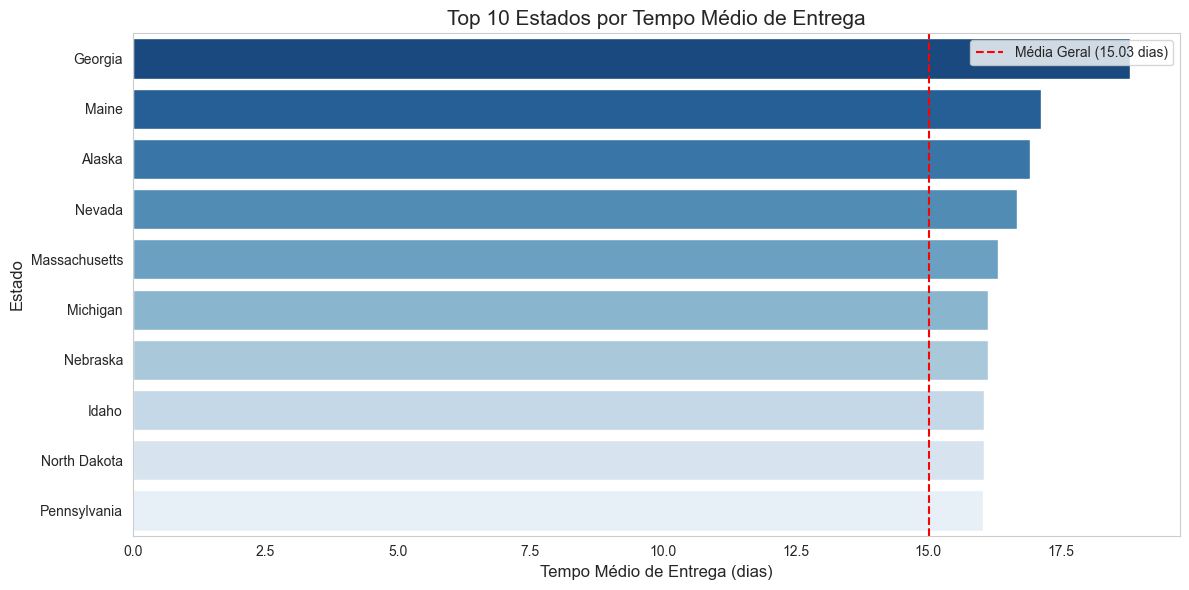

In [379]:
# 2. Calcular tempo médio por estado
media_por_estado = (
    df_logistic.groupby('state')['delivery_time']
    .mean()
    .reset_index()
    .sort_values(by='delivery_time', ascending=False)
)

# 3. Selecionar apenas o Top 10
top10_estados = media_por_estado.head(10)

# 4. Calcular tempo médio geral (linha de referência)
tempo_medio_geral = df_logistic['delivery_time'].mean()

# 5. Criar gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10_estados,
    x='delivery_time',
    y='state',
    palette='Blues_r'
)

# Adicionar linha horizontal com tempo médio geral
plt.axvline(tempo_medio_geral, color='red', linestyle='--', label=f'Média Geral ({tempo_medio_geral:.2f} dias)')

# Customização
plt.title('Top 10 Estados por Tempo Médio de Entrega', fontsize=15)
plt.xlabel('Tempo Médio de Entrega (dias)', fontsize=12)
plt.ylabel('Estado', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()


- Quantos pedidos foram feitos fora do prazo por estado?

In [380]:
# 2. Calcular tempo médio por região (exemplo: por estado)
media_por_estado = df_logistic.groupby('state')['delivery_time'].mean().reset_index()
media_por_estado.columns = ['state', 'tempo_medio_estado']

# 3. Juntar a média de cada estado de volta ao df_logistic
df_logistic = df_logistic.merge(media_por_estado, on='state', how='left')

# 4. Criar coluna indicando se o envio foi fora do tempo médio
df_logistic['fora_do_tempo_medio'] = df_logistic['delivery_time'] > df_logistic['tempo_medio_estado']

# 5. Contar quantos envios foram fora do tempo médio por estado
envios_fora = (
    df_logistic.groupby('state')['fora_do_tempo_medio']
    .sum()
    .reset_index()
    .sort_values(by='fora_do_tempo_medio', ascending=False)
)

# Renomear coluna para clareza
envios_fora.columns = ['Estado', 'Envios_Fora_do_Tempo_Médio']

print("--- Envios Fora do Tempo Médio por Estado ---")
envios_fora.head(10)  # mostra os 10 estados com mais envios fora do tempo médio


--- Envios Fora do Tempo Médio por Estado ---


,Estado,Envios_Fora_do_Tempo_Médio
30,New Mexico,44
7,Delaware,42
32,North Carolina,41
47,West Virginia,40
19,Maryland,39
38,Rhode Island,39
24,Missouri,39
49,Wyoming,38
8,Florida,38
5,Colorado,37


- Criando dataframe com todos os envios que foram feitos fora do prazo

In [381]:
# Filtrar pedidos de New Mexico fora do tempo médio
df_envios_fora_prazo = df_logistic[
    (df_logistic['fora_do_tempo_medio'] == True)
]

# Mostrar apenas uma amostra (exemplo: 10 primeiros registros)
print("--- Amostra de Pedidos Fora do Tempo Médio - Geral ---")
df_envios_fora_prazo.head(10)


--- Amostra de Pedidos Fora do Tempo Médio - Geral ---


,order_id,order_date,ship_date,delivery_date,state,city,product_name,category,sub_category,brand,shipping_cost,total_sales,dispatch_time,delivery_time,shipping_impact_%,tempo_medio_estado,fora_do_tempo_medio
0,A10001,2026-01-20,2026-02-03,2026-02-03,Tennessee,Madisonmouth,school,Home,Furniture,Davis LLC,112.96,55043.88,14,14,0.21,13.61,True
2,A10006,2026-01-04,2026-01-10,2026-01-21,Colorado,Turnerville,page,Electronics,Mobile,Wade-Jackson,29.90,156361.68,6,17,0.02,15.48,True
3,A10009,2026-01-24,2026-01-26,2026-02-10,South Carolina,Kendraton,example,Fashion,Clothing,"Carroll, Barnes and Harris",144.57,74836.31,2,17,0.19,15.55,True
4,A10011,2026-01-17,2026-01-17,2026-02-06,Georgia,Lawrenceland,experience,Home,Furniture,Johns and Sons,57.50,15576.08,0,20,0.37,18.81,True
7,A10017,2026-01-01,2026-02-08,2026-01-20,Oklahoma,Mariafort,themselves,Home,Kitchen,Steele-Butler,27.80,23670.32,38,19,0.12,14.81,True
8,A10028,2026-01-05,2026-01-21,2026-01-24,Pennsylvania,Dwaynehaven,set,Electronics,Laptop,Valdez Ltd,45.35,28490.53,16,19,0.16,16.04,True
9,A10030,2026-01-16,2026-01-21,2026-02-10,Pennsylvania,North Sara,recognize,Electronics,Accessories,Shaw Group,125.58,176016.99,5,25,0.07,16.04,True
10,A10031,2026-01-06,2026-01-17,2026-02-04,Arizona,South Roberta,ability,Home,Furniture,"Fowler, Luna and Johnson",147.05,42960.16,11,29,0.34,12.79,True
12,A10044,2026-01-07,2026-01-18,2026-02-10,Rhode Island,Mikaylastad,back,Electronics,Laptop,"Ray, Carr and Peterson",42.74,187334.61,11,34,0.02,15.83,True
14,A10065,2026-01-14,2026-01-15,2026-02-04,Colorado,North Matthew,house,Home,Furniture,"Lewis, Bishop and Smith",27.97,49182.87,1,21,0.06,15.48,True


In [382]:
df_envios_fora_prazo.shape

(1612, 17)

### Gráfico de Pareto

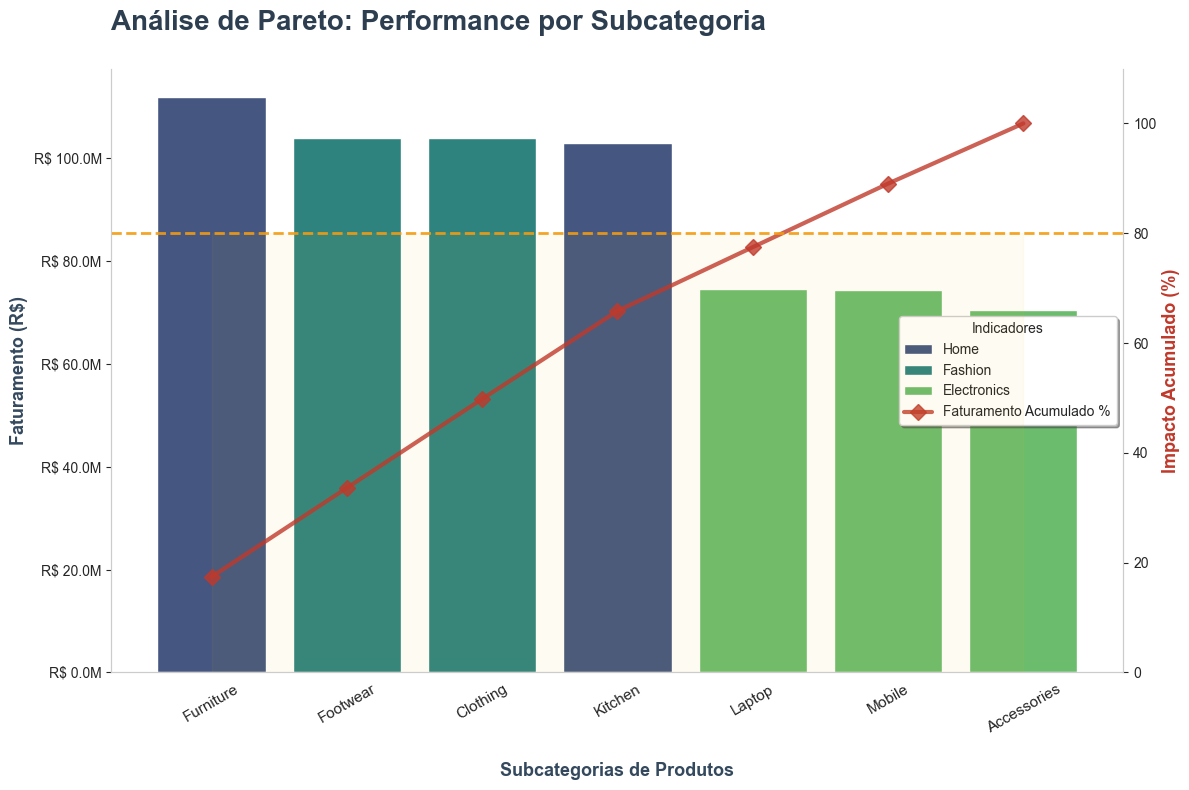

In [383]:
# 1. Preparação dos dados por Subcategoria
pareto_sub = df1.groupby(['sub_category', 'category'])['total_sales'].sum().sort_values(ascending=False).reset_index()
pareto_sub['cum_percent'] = (pareto_sub['total_sales'].cumsum() / pareto_sub['total_sales'].sum()) * 100

# 2. Configuração estética do Matplotlib
sns.set_style("whitegrid", {'axes.grid': False}) # Fundo limpo
fig, ax1 = plt.subplots(figsize=(12, 8))

# 3. Gráfico de Barras - Estilizado
# Usando a paleta 'mako' ou 'flare' para um ar mais moderno
barras = sns.barplot(
    data=pareto_sub, 
    x='sub_category', 
    y='total_sales', 
    hue='category', 
    ax=ax1, 
    dodge=False, 
    palette='viridis',
    edgecolor='white',
    linewidth=1
)

# 4. Linha de Pareto - Estilizada
ax2 = ax1.twinx()
ax2.plot(
    pareto_sub['sub_category'], 
    pareto_sub['cum_percent'], 
    color='#C0392B', # Vermelho elegante
    marker='D',      # Marcador em diamante
    markersize=8, 
    linewidth=3, 
    label='Faturamento Acumulado %',
    alpha=0.8
)

# 5. Destaque da Regra 80/20
ax2.axhline(80, color='#F39C12', linestyle='--', linewidth=2, alpha=0.9)
ax2.fill_between(pareto_sub['sub_category'], 0, 80, color='#F1C40F', alpha=0.05) # Área de destaque suave

# 6. Refinamento de Labels e Títulos
ax1.set_title('Análise de Pareto: Performance por Subcategoria\n', fontsize=20, fontweight='bold', loc='left', color='#2C3E50')
ax1.set_ylabel('Faturamento (R$)', fontsize=13, fontweight='semibold', color='#34495E')
ax1.set_xlabel('\nSubcategorias de Produtos', fontsize=13, fontweight='semibold', color='#34495E')
ax1.tick_params(axis='x', rotation=30, labelsize=11)

# Formatação do Eixo Y para Moeda (K para milhar, M para Milhão)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'R$ {x/1e6:,.1f}M'))
ax2.set_ylabel('Impacto Acumulado (%)', fontsize=13, fontweight='semibold', color='#C0392B')
ax2.set_ylim(0, 110)

# 7. Legendas Organizadas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right', title='Indicadores', frameon=True, shadow=True)

sns.despine(right=False, top=True) # Remove bordas desnecessárias
plt.tight_layout()
plt.show()